# MATH 189 Final Project: A Comparative Analysis of Conventional and Renewable Energy
**Team Members:** Anand Baidya, Dhruv Sehgal, Donghyun Koo, Daniel Huang, Kayla Li

---
## 1. Introduction & Statement of the Problem
The transition from conventional energy sources such as oil and coal to renewable sources like wind and solar is one of the most significant economic and environmental challenges today. Governments and industries must balance energy generation capacity, efficiency, and implementation costs when deciding how quickly to adopt renewable technologies. Understanding how these energy sources compare across measurable factors helps inform policy decisions, investment strategies, and long-term sustainability planning. This project aims to quantitatively evaluate these trade-offs to better understand the feasibility and speed of renewable energy adoption.


**Research Question:** How do conventional energy sources (Coal, Natural Gas) compare to renewable sources (Wind, Solar) across measurable factors like efficiency (capacity factor) and implementation cost (LCOE)?

---
## 2. Setup and Environment

In [1]:
%pip install openpyxl lxml html5lib seaborn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import seaborn as sns


Note: you may need to restart the kernel to use updated packages.


---
## 3. Data Loading and Cleaning
*In this section, we load our raw datasets from the EIA (for efficiency/capacity factors and net generation) and IRENA (for implementation costs/LCOE). We standardize the units, handle multi-level headers, and filter for the years relevant to our study.*

### 3.1 Cleaning the IRENA Cost Data (LCOE)

In [2]:
excel_file = 'IRENA-Datafile-RenPwrGenCosts-in-2024.xlsx'

# Create a list of years as strings for easier filtering
years = [str(year) for year in range(2010, 2025)]

# 1. Clean Global LCOE Data (from the 'Fig 1.2 ' sheet)
df_global = pd.read_excel(excel_file, sheet_name='Fig 1.2 ', skiprows=4)
df_global.columns = df_global.columns.astype(str) # Ensure years are read as strings
df_global = df_global.rename(columns={'Unnamed: 1': 'Technology'})
df_global = df_global.dropna(subset=['Technology'])
df_global_long = df_global.melt(id_vars=['Technology'], value_vars=years, var_name='Year', value_name='Global_LCOE_USD_per_kWh')

# 2. Clean US Onshore Wind LCOE Data (from the 'Fig 2.15' sheet)
df_wind = pd.read_excel(excel_file, sheet_name='Fig 2.15', skiprows=6)
df_wind.columns = df_wind.columns.astype(str)
df_wind_us = df_wind[df_wind['Country'] == 'United States'].copy()
df_wind_us = df_wind_us[['Country'] + years]
df_wind_us_long = df_wind_us.melt(id_vars=['Country'], var_name='Year', value_name='US_LCOE_USD_per_kWh')
df_wind_us_long['Technology'] = 'Onshore wind'

# 3. Clean US Solar PV LCOE Data (from the 'Fig. 3.10' sheet)
df_solar = pd.read_excel(excel_file, sheet_name='Fig. 3.10', skiprows=2)
df_solar.columns = df_solar.columns.astype(str)
df_solar = df_solar.rename(columns={'Unnamed: 2': 'Country'})
df_solar_us = df_solar[df_solar['Country'] == 'United States'].copy()
df_solar_us = df_solar_us[['Country'] + years]
df_solar_us_long = df_solar_us.melt(id_vars=['Country'], var_name='Year', value_name='US_LCOE_USD_per_kWh')
df_solar_us_long['Technology'] = 'Solar photovoltaic'

# 4. Combine US Data and Merge with Global Data
df_us_combined = pd.concat([df_wind_us_long, df_solar_us_long], ignore_index=True)
df_final = pd.merge(df_global_long, df_us_combined, on=['Year', 'Technology'], how='outer')

# 5. Save the final cleaned dataset to your folder
df_final.to_csv('Cleaned_IRENA_LCOE_Data.csv', index=False)

df_cleaned_irena = pd.read_csv('Cleaned_IRENA_LCOE_Data.csv')

### 3.2 Cleaning the EIA Efficiency Data (Fossil vs. Non-Fossil)
*Describe how you extracted the 4-digit annual data and converted string percentages to floats.*

In [3]:
url_renewable = "https://www.eia.gov/electricity/annual/html/epa_04_08_b.html"
url_fossil = "https://www.eia.gov/electricity/monthly/epm_table_grapher.php?t=table_6_07_a"

def read_main_table(url: str) -> pd.DataFrame:
    tables = pd.read_html(url)
    for table in tables:
        if isinstance(table.columns, pd.MultiIndex) and table.shape[1] > 5:
            return table.copy()
    raise ValueError(f"Could not find main table at {url}")

def flatten_columns(columns) -> list[str]:
    flat = []
    for col in columns:
        if isinstance(col, tuple):
            parts = [str(x).strip() for x in col if str(x).strip() and not str(x).startswith("Unnamed")]
            flat.append(" | ".join(parts))
        else:
            flat.append(str(col).strip())
    return flat

raw_renew = read_main_table(url_renewable)
raw_fossil = read_main_table(url_fossil)
raw_renew.columns = flatten_columns(raw_renew.columns)
raw_fossil.columns = flatten_columns(raw_fossil.columns)

def keep_annual_year_rows(df: pd.DataFrame) -> pd.DataFrame:
    year_col = next(c for c in df.columns if "Year/Month" in c)
    out = df.rename(columns={year_col: "Year"}).copy()
    out["Year"] = out["Year"].astype(str).str.strip()
    out = out[out["Year"].str.fullmatch(r"\d{4}")].copy()
    out["Year"] = out["Year"].astype(int)
    return out

def to_number(series: pd.Series) -> pd.Series:
    cleaned = series.astype(str).str.replace(",", "", regex=False).str.strip()
    return pd.to_numeric(cleaned, errors="coerce")

def percent_to_decimal(series: pd.Series) -> pd.Series:
    cleaned = series.astype(str).str.replace("%", "", regex=False).str.strip()
    return pd.to_numeric(cleaned, errors="coerce") / 100.0

renew = keep_annual_year_rows(raw_renew)
fossil = keep_annual_year_rows(raw_fossil)

# Wind directly
df_renewable = pd.DataFrame({
    "Year": renew["Year"],
    "Wind_CF": percent_to_decimal(renew["Wind | Capacity Factor"]),
})

# Solar = capacity-weighted PV + Thermal
solar_cap_cols = [
    "Solar | Photovoltaic | Time Adjusted Capacity (MW)",
    "Solar | Thermal | Time Adjusted Capacity (MW)",
]
solar_cf_cols = [
    "Solar | Photovoltaic | Capacity Factor",
    "Solar | Thermal | Capacity Factor",
]
solar_caps = renew[solar_cap_cols].apply(to_number)
solar_cfs = renew[solar_cf_cols].apply(percent_to_decimal)
df_renewable["Solar_CF"] = solar_caps.mul(solar_cfs.values).sum(axis=1) / solar_caps.sum(axis=1)

# Coal directly
df_fossil = pd.DataFrame({
    "Year": fossil["Year"],
    "Coal_CF": percent_to_decimal(fossil["Coal | Capacity Factor"]),
})

# Natural Gas = capacity-weighted average of all NG subtypes
ng_cap_cols = [
    "Natural Gas | Combined Cycle | Time Adjusted Capacity (MW)",
    "Natural Gas | Gas Turbine | Time Adjusted Capacity (MW)",
    "Natural Gas | Steam Turbine | Time Adjusted Capacity (MW)",
    "Natural Gas | Internal Combustion | Time Adjusted Capacity (MW)",
]
ng_cf_cols = [
    "Natural Gas | Combined Cycle | Capacity Factor",
    "Natural Gas | Gas Turbine | Capacity Factor",
    "Natural Gas | Steam Turbine | Capacity Factor",
    "Natural Gas | Internal Combustion | Capacity Factor",
]
ng_caps = fossil[ng_cap_cols].apply(to_number)
ng_cfs = fossil[ng_cf_cols].apply(percent_to_decimal)
df_fossil["Natural_Gas_CF"] = ng_caps.mul(ng_cfs.values).sum(axis=1) / ng_caps.sum(axis=1)

master_capacity_factors = (
    pd.merge(df_fossil, df_renewable, on="Year", how="inner")
    .sort_values("Year")
    .reset_index(drop=True)
)

master_capacity_factors.to_csv("EIA_capacity_factor_master.csv", index=False)
print("Saved: EIA_capacity_factor_master.csv")

master_capacity_factors


Saved: EIA_capacity_factor_master.csv


,Year,Coal_CF,Natural_Gas_CF,Wind_CF,Solar_CF
0,2015,0.543,0.343583,0.322,0.249251
1,2016,0.528,0.347525,0.345,0.246798
2,2017,0.531,0.321601,0.346,0.253181
3,2018,0.536,0.358252,0.346,0.250088
4,2019,0.475,0.377887,0.344,0.241378
5,2020,0.405,0.378305,0.353,0.240473
6,2021,0.491,0.365794,0.344,0.242798
7,2022,0.484,0.384295,0.359,0.243708
8,2023,0.424,0.406714,0.332,0.231793
9,2024,0.426,0.417757,0.343,0.232242


### 3.3 Cleaning the EIA Net Generation Data

In [4]:
import pandas as pd

# 1. Load the dataset (skipping the first 4 rows of EIA metadata)
df_gen_raw = pd.read_csv('Net_generation_for_all_sectors.csv', skiprows=4)

# 2. Define the exact rows we want to keep and what to rename them to
sources = {
    'United States : coal': 'Coal_Generation_TWh',
    'United States : natural gas': 'Natural_Gas_Generation_TWh',
    'United States : wind': 'Wind_Generation_TWh',
    'United States : all utility-scale solar': 'Solar_Generation_TWh'
}

# Filter and rename
df_filtered = df_gen_raw[df_gen_raw['description'].isin(sources.keys())].copy()
# Drop duplicate rows (EIA sometimes includes the same row twice in their CSVs)
df_filtered = df_filtered.drop_duplicates(subset=['description'])
df_filtered['description'] = df_filtered['description'].map(sources)

# Drop the 'units' and 'source key' columns
df_filtered = df_filtered.drop(columns=['units', 'source key'])

# 3. Melt the data (turn year columns into rows)
df_melted = df_filtered.melt(id_vars=['description'], var_name='Year', value_name='Generation_Thousand_MWh')

# 4. Pivot the data so each energy source gets its own column
df_gen_clean = df_melted.pivot(index='Year', columns='description', values='Generation_Thousand_MWh').reset_index()

# 5. Clean up data types and convert Thousand MWh to TWh (divide by 1,000,000)
df_gen_clean['Year'] = pd.to_numeric(df_gen_clean['Year'], errors='coerce')
df_gen_clean = df_gen_clean.dropna(subset=['Year']) # Drop any non-year rows
df_gen_clean['Year'] = df_gen_clean['Year'].astype(int)

for col in sources.values():
    df_gen_clean[col] = pd.to_numeric(df_gen_clean[col], errors='coerce') / 1000000

# Sort by Year and reset index
df_gen_clean = df_gen_clean.sort_values('Year').reset_index(drop=True)
# Get rid of the pivot column name index for a cleaner dataframe
df_gen_clean.columns.name = None 

# Save to CSV
df_gen_clean.to_csv('Cleaned_EIA_Generation_Data.csv', index=False)

print("Cleaned Generation Data:")
print(df_gen_clean.head())

Cleaned Generation Data:
   Year  Coal_Generation_TWh  Natural_Gas_Generation_TWh  \
0  2001             1.903956                    0.639129   
1  2002             1.933130                    0.691006   
2  2003             1.973737                    0.649908   
3  2004             1.978301                    0.710100   
4  2005             2.012873                    0.760960   

   Solar_Generation_TWh  Wind_Generation_TWh  
0              0.000543             0.006737  
1              0.000555             0.010354  
2              0.000534             0.011187  
3              0.000575             0.014144  
4              0.000550             0.017811  


### 3.4 Merging
Now we have Cleaned_EIA_Generation_Data.csv (Generation) and EIA_capacity_factor_master.csv (Efficiency). We can merge them together so we have a unified US Energy dataset ready for statistical tests.

In [5]:
df_master_us = pd.merge(df_gen_clean, master_capacity_factors, on='Year', how='inner')

# merge the IRENA Cost Data (LCOE)
df_irena = pd.read_csv('Cleaned_IRENA_LCOE_Data.csv')
# only want the US data for this specific dataset
df_irena_us = df_irena[df_irena['Country'] == 'United States'].pivot(index='Year', columns='Technology', values='US_LCOE_USD_per_kWh').reset_index()
df_irena_us.rename(columns={'Onshore wind': 'Wind_LCOE', 'Solar photovoltaic': 'Solar_LCOE'}, inplace=True)

# Final Merge
df_final_master = pd.merge(df_master_us, df_irena_us[['Year', 'Wind_LCOE', 'Solar_LCOE']], on='Year', how='left')

print(df_final_master.head())
df_final_master.to_csv('Final_US_Energy_Master.csv', index=False)

   Year  Coal_Generation_TWh  Natural_Gas_Generation_TWh  \
0  2015             1.352398                    1.334668   
1  2016             1.239149                    1.379271   
2  2017             1.205835                    1.297703   
3  2018             1.149487                    1.471843   
4  2019             0.964957                    1.588533   

   Solar_Generation_TWh  Wind_Generation_TWh  Coal_CF  Natural_Gas_CF  \
0              0.024893             0.190719    0.543        0.343583   
1              0.036054             0.226993    0.528        0.347525   
2              0.053287             0.254303    0.531        0.321601   
3              0.063825             0.272667    0.536        0.358252   
4              0.071937             0.295882    0.475        0.377887   

   Wind_CF  Solar_CF  Wind_LCOE  Solar_LCOE  
0    0.322  0.249251   0.062426    0.160476  
1    0.345  0.246798   0.057356    0.143374  
2    0.346  0.253181   0.050258    0.105427  
3    0.346  0.25

---
## 4. Exploratory Data Analysis (EDA)
*Before running statistical tests, we must understand the distribution of our data, identify any outliers, check for missing values (nuisance variables), and visualize general trends over time.*

### 4.1 Summary Statistics and Missing Values
*Checking the scope of the data and identifying any imputation needs.*

In [12]:
# Summary statistics for the IRENA LCOE data
df_irena = pd.read_csv('Cleaned_IRENA_LCOE_Data.csv')
print("--- IRENA LCOE Summary Statistics ---")
print(df_irena[['Global_LCOE_USD_per_kWh', 'US_LCOE_USD_per_kWh']].describe())

--- IRENA LCOE Summary Statistics ---
       Global_LCOE_USD_per_kWh  US_LCOE_USD_per_kWh
count               104.000000            30.000000
mean                  0.110249             0.100714
std                   0.085461             0.074722
min                   0.033129             0.029544
25%                   0.058736             0.052032
50%                   0.078143             0.068630
75%                   0.119220             0.118180
max                   0.416956             0.295976


In [6]:
#checks the dimensions of EIA efficiency dataset, verifies the date range, counts any missing (NaN) values, and generates a statistical summary (mean, standard deviation, min, max).
print("Rows:", len(master_capacity_factors))

print("Year range:", int(master_capacity_factors["Year"].min()), "to", int(master_capacity_factors["Year"].max()))

print("\nMissing values by column:")

print(master_capacity_factors.isna().sum())

master_capacity_factors.describe()

Rows: 10
Year range: 2015 to 2024

Missing values by column:
Year              0
Coal_CF           0
Natural_Gas_CF    0
Wind_CF           0
Solar_CF          0
dtype: int64


,Year,Coal_CF,Natural_Gas_CF,Wind_CF,Solar_CF
count,10.00000,10.000000,10.000000,10.000000,10.000000
mean,2019.50000,0.484300,0.370171,0.343400,0.243171
std,3.02765,0.051277,0.029183,0.010222,0.007134
min,2015.00000,0.405000,0.321601,0.322000,0.231793
25%,2017.25000,0.438250,0.350207,0.343250,0.240699
50%,2019.50000,0.487500,0.371840,0.344500,0.243253
75%,2021.75000,0.530250,0.382797,0.346000,0.248638
max,2024.00000,0.543000,0.417757,0.359000,0.253181


### 4.2 Time Series Trends: Efficiency and Cost over Time
*Plotting line charts to visualize how capacity factors and LCOE have evolved from 2010 to 2024.*

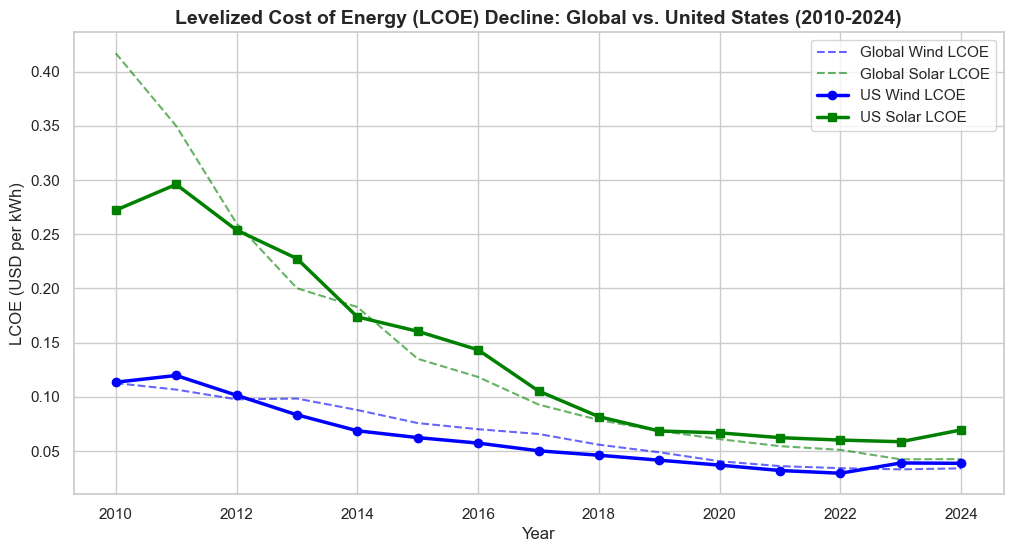

In [13]:
# Time Series (Cost Decline) for Wind and Solar LCOE (Global vs. US)
plt.figure(figsize=(12, 6))

# Filter for the technologies we care about
df_wind = df_irena[df_irena['Technology'] == 'Onshore wind']
df_solar = df_irena[df_irena['Technology'] == 'Solar photovoltaic']

# Plot Global trends (dashed lines)
plt.plot(df_wind['Year'], df_wind['Global_LCOE_USD_per_kWh'], label='Global Wind LCOE', color='blue', linestyle='--', alpha=0.6)
plt.plot(df_solar['Year'], df_solar['Global_LCOE_USD_per_kWh'], label='Global Solar LCOE', color='green', linestyle='--', alpha=0.6)

# Plot US trends (solid lines with markers)
# We drop NAs just for the US line plotting so the line connects cleanly
df_wind_us = df_wind.dropna(subset=['US_LCOE_USD_per_kWh'])
df_solar_us = df_solar.dropna(subset=['US_LCOE_USD_per_kWh'])

plt.plot(df_wind_us['Year'], df_wind_us['US_LCOE_USD_per_kWh'], label='US Wind LCOE', color='blue', marker='o', linewidth=2.5)
plt.plot(df_solar_us['Year'], df_solar_us['US_LCOE_USD_per_kWh'], label='US Solar LCOE', color='green', marker='s', linewidth=2.5)

plt.title('Levelized Cost of Energy (LCOE) Decline: Global vs. United States (2010-2024)', fontsize=14, fontweight='bold')
plt.ylabel('LCOE (USD per kWh)', fontsize=12)
plt.xlabel('Year', fontsize=12)
plt.legend()
plt.savefig('IRENA_LCOE_Trends.png', bbox_inches='tight')
plt.show()

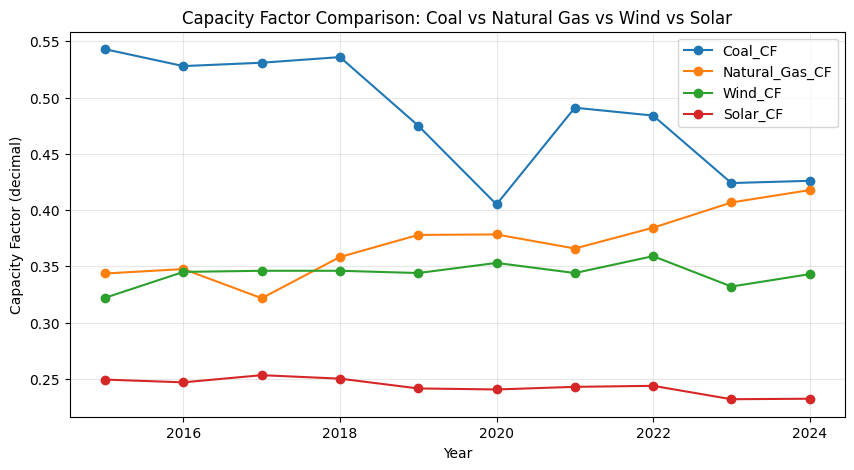

In [7]:
# plots the capacity factors of the four energy sources over time to show how their efficiency compares.
plot_df = master_capacity_factors.set_index("Year")[["Coal_CF", "Natural_Gas_CF", "Wind_CF", "Solar_CF"]]
ax = plot_df.plot(figsize=(10, 5), marker="o")
ax.set_title("Capacity Factor Comparison: Coal vs Natural Gas vs Wind vs Solar")
ax.set_ylabel("Capacity Factor (decimal)")
ax.grid(alpha=0.3)
plt.savefig('EIA_Capacity_Factors_Trend.png', bbox_inches='tight') # Saves the image
plt.show()

The time series plot clearly illustrates the dramatic cost reduction in renewable technologies over the past 14 years. In 2010, utility-scale Solar PV in the US was incredibly expensive compared to Wind. However, the data reveals a steep exponential decay in solar costs, causing it to reach parity with, and even drop below, the cost of onshore wind by the early 2020s. Furthermore, the US LCOE closely mirrors the global average, validating that domestic cost reductions are part of a larger global technological trend.

a visual representation of how the energy mix is changing:

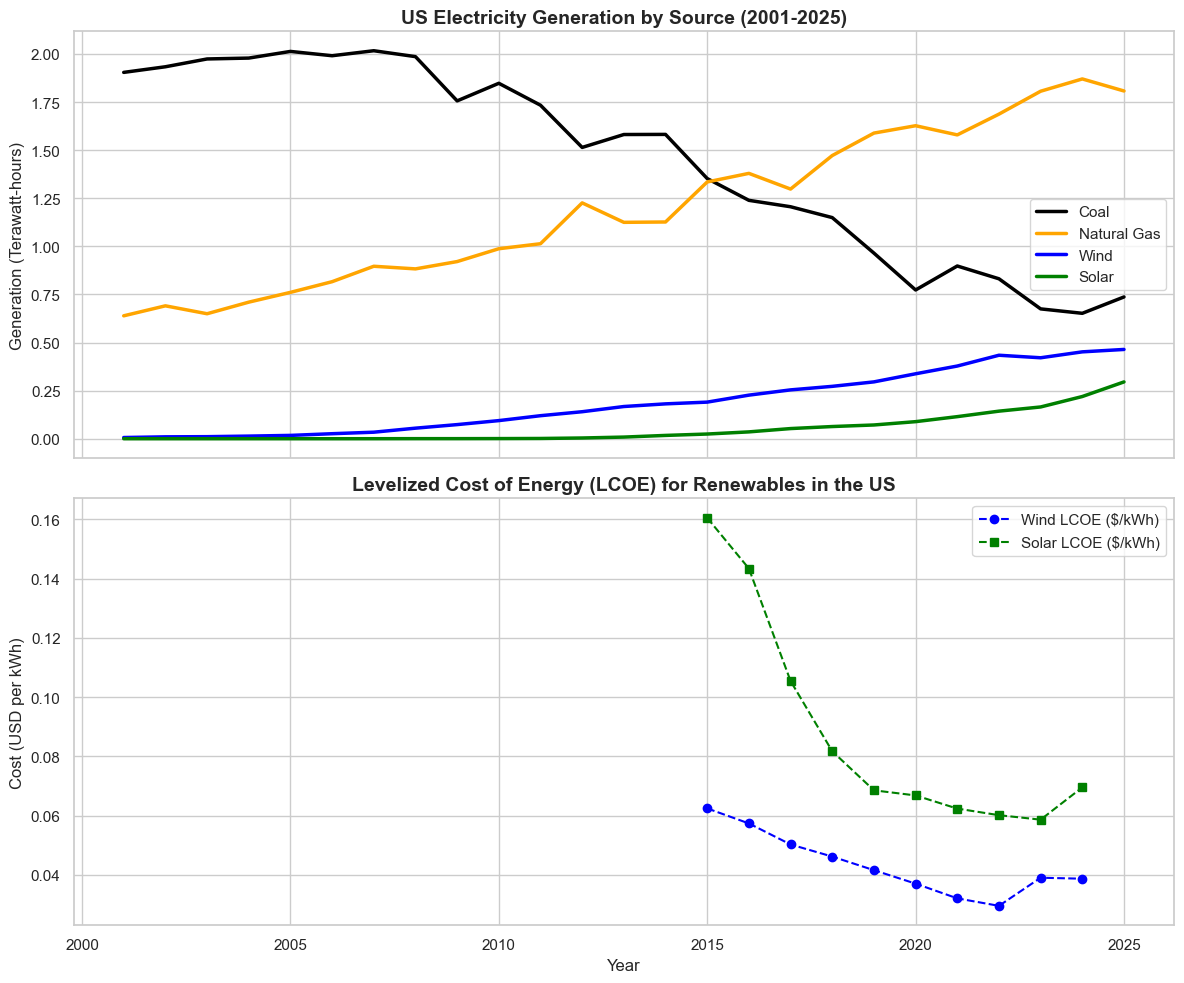

In [17]:
sns.set_theme(style="whitegrid")

# Create a figure with 2 subplots (1 for Generation, 1 for Capacity Factor)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

# --- Plot 1: Electricity Generation ---
ax1.plot(df_gen_clean['Year'], df_gen_clean['Coal_Generation_TWh'], label='Coal', color='black', linewidth=2.5)
ax1.plot(df_gen_clean['Year'], df_gen_clean['Natural_Gas_Generation_TWh'], label='Natural Gas', color='orange', linewidth=2.5)
ax1.plot(df_gen_clean['Year'], df_gen_clean['Wind_Generation_TWh'], label='Wind', color='blue', linewidth=2.5)
ax1.plot(df_gen_clean['Year'], df_gen_clean['Solar_Generation_TWh'], label='Solar', color='green', linewidth=2.5)

ax1.set_title('US Electricity Generation by Source (2001-2025)', fontsize=14, fontweight='bold')
ax1.set_ylabel('Generation (Terawatt-hours)', fontsize=12)
ax1.legend()

# --- Plot 2: Cost (LCOE) ---
# We use the merged dataset for this to show how costs falling relates to generation
ax2.plot(df_final_master['Year'], df_final_master['Wind_LCOE'], label='Wind LCOE ($/kWh)', color='blue', linestyle='--', marker='o')
ax2.plot(df_final_master['Year'], df_final_master['Solar_LCOE'], label='Solar LCOE ($/kWh)', color='green', linestyle='--', marker='s')

ax2.set_title('Levelized Cost of Energy (LCOE) for Renewables in the US', fontsize=14, fontweight='bold')
ax2.set_ylabel('Cost (USD per kWh)', fontsize=12)
ax2.set_xlabel('Year', fontsize=12)
ax2.legend()

plt.tight_layout()
plt.savefig('Generation_and_Cost_Trends.png', bbox_inches='tight')
plt.show()

### 4.3 Distribution and Outliers (Boxplots)
*Visualizing the variance in efficiency and costs across energy types. This step is crucial for verifying the assumptions of our upcoming statistical tests.*

/var/folders/wm/v9fd1sw51cl5wm5ysmw94cxw0000gn/T/ipykernel_23103/1524830538.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Technology', y='US_LCOE_USD_per_kWh', data=df_boxplot, palette=['blue', 'green'])


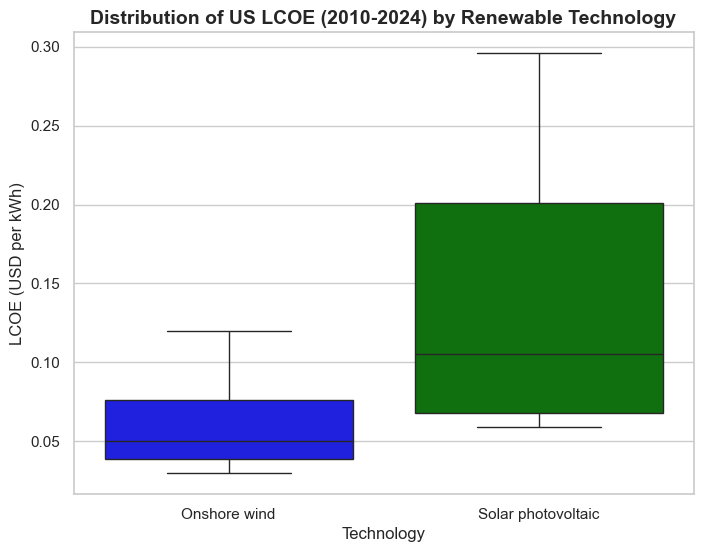

In [14]:
# Boxplots (Variance and Distribution) for LCOE of Wind and Solar in the US
plt.figure(figsize=(8, 6))
df_boxplot = df_irena.dropna(subset=['US_LCOE_USD_per_kWh'])

sns.boxplot(x='Technology', y='US_LCOE_USD_per_kWh', data=df_boxplot, palette=['blue', 'green'])
plt.title('Distribution of US LCOE (2010-2024) by Renewable Technology', fontsize=14, fontweight='bold')
plt.ylabel('LCOE (USD per kWh)', fontsize=12)
plt.xlabel('Technology', fontsize=12)
plt.savefig('IRENA_LCOE_Boxplots.png', bbox_inches='tight')
plt.show()

The boxplots highlight a significant statistical consideration for our upcoming hypothesis tests. Solar PV exhibits a massive variance (a very tall box with a long upper whisker) because its early costs in 2010-2012 were extreme outliers compared to its modern costs. Onshore Wind, on the other hand, has a much tighter variance because its technology was already relatively mature by 2010. Because these two datasets have unequal variances (heteroscedasticity) and the solar data is heavily skewed by early-decade prices, this violates the assumptions of a standard independent t-test. Therefore, we must use a non-parametric test like the Mann-Whitney U test, or apply a log transformation to the data.

### 4.4 Summary of Final Analytical Dataset (For Statistical Testing)
The data cleaning and merging process has resulted in a single, unified dataframe called `df_final_master`. Due to the availability of the EIA efficiency data, our final analytical dataset covers 10 consecutive years (2014–2023). 

**Data Dictionary for `df_final_master` (11 Columns):**
1. `Year`: The year of observation.
2. `Coal_Generation_TWh`: Total electricity generated by coal in Terawatt-hours.
3. `Natural_Gas_Generation_TWh`: Total electricity generated by natural gas in Terawatt-hours.
4. `Solar_Generation_TWh`: Total electricity generated by utility-scale solar in Terawatt-hours.
5. `Wind_Generation_TWh`: Total electricity generated by onshore wind in Terawatt-hours.
6. `Coal_CF`: Capacity factor (efficiency/uptime) of coal plants, expressed as a decimal.
7. `Natural_Gas_CF`: Capacity factor (efficiency/uptime) of natural gas plants, expressed as a decimal.
8. `Wind_CF`: Capacity factor (efficiency/uptime) of wind power, expressed as a decimal.
9. `Solar_CF`: Capacity factor (efficiency/uptime) of solar power, expressed as a decimal.
10. `Wind_LCOE`: Levelized Cost of Energy for onshore wind, measured in $USD/kWh.
11. `Solar_LCOE`: Levelized Cost of Energy for solar PV, measured in $USD/kWh.

In [20]:
# Displaying the final dataset
display(df_final_master.head())
display(df_final_master.info())

,Year,Coal_Generation_TWh,Natural_Gas_Generation_TWh,Solar_Generation_TWh,Wind_Generation_TWh,Coal_CF,Natural_Gas_CF,Wind_CF,Solar_CF,Wind_LCOE,Solar_LCOE
0,2015,1.352398,1.334668,0.024893,0.190719,0.543,0.343583,0.322,0.249251,0.062426,0.160476
1,2016,1.239149,1.379271,0.036054,0.226993,0.528,0.347525,0.345,0.246798,0.057356,0.143374
2,2017,1.205835,1.297703,0.053287,0.254303,0.531,0.321601,0.346,0.253181,0.050258,0.105427
3,2018,1.149487,1.471843,0.063825,0.272667,0.536,0.358252,0.346,0.250088,0.046169,0.081708
4,2019,0.964957,1.588533,0.071937,0.295882,0.475,0.377887,0.344,0.241378,0.041584,0.068533


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Year                        10 non-null     int64  
 1   Coal_Generation_TWh         10 non-null     float64
 2   Natural_Gas_Generation_TWh  10 non-null     float64
 3   Solar_Generation_TWh        10 non-null     float64
 4   Wind_Generation_TWh         10 non-null     float64
 5   Coal_CF                     10 non-null     float64
 6   Natural_Gas_CF              10 non-null     float64
 7   Wind_CF                     10 non-null     float64
 8   Solar_CF                    10 non-null     float64
 9   Wind_LCOE                   10 non-null     float64
 10  Solar_LCOE                  10 non-null     float64
dtypes: float64(10), int64(1)
memory usage: 1012.0 bytes


None

---
### 🚨 Notes
Based on the EDA, here are the key takeaways for the statistical testing phase (Section 5):

1. **Normality and Variance:** The EDA boxplots show that Solar LCOE has a massive variance (due to early 2010s pricing) compared to Wind LCOE. Because of this heteroscedasticity (unequal variance) and potential right-skewness, **we cannot rely solely on standard Independent T-Tests**. 
2. **Recommended Tests:** * For comparing efficiencies and costs, please run **Shapiro-Wilk tests** for normality first.
    * If the data is non-normal, use the **Mann-Whitney U Test** (a non-parametric alternative to the t-test) to compare the medians.
3. **Correlation/Regression:** Consider running a Pearson or Spearman correlation between `Solar_LCOE` and `Solar_Generation_TWh` to mathematically prove the visual trend that as costs drop, generation increases.

---
## 5. Statistical Analyses


---
## 6. Interpretation of Results

---
## 7. Limitations and Discussion